In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE  = "/content/drive/MyDrive/EyeMotionID"
PLOTS = os.path.join(BASE, "results/plots")
REPORTS = os.path.join(BASE, "results/reports")
os.makedirs(PLOTS,   exist_ok=True)
os.makedirs(REPORTS, exist_ok=True)

print("✓ Drive mounted")
print("✓ Plots path  :", os.path.exists(PLOTS))
print("✓ Reports path:", os.path.exists(REPORTS))

Mounted at /content/drive
✓ Drive mounted
✓ Plots path  : True
✓ Reports path: True


##Complete results summary table

In [2]:
import pandas as pd

# all experiment results
results = {
    "Experiment"  : [
        "CNN+LSTM (15 users)",
        "CNN+GRU (15 users)",
        "MobileNetV2+LSTM (15 users)",
        "MobileNetV2+GRU (15 users)",
        "CNN+LSTM (51 users) ★",
    ],
    "Users"       : [15, 15, 15, 15, 51],
    "Accuracy (%)" : [98.89, 98.22, 99.56, 100.00, 95.88],
    "Precision (%)": [98.92, 98.21, 99.55, 100.00, 96.52],
    "Recall (%)"   : [98.89, 98.22, 99.56, 100.00, 95.88],
    "F1-Score (%)" : [98.88, 98.21, 99.55, 100.00, 95.76],
    "Baseline (%)" : [6.67,  6.67,  6.67,  6.67,  1.96],
}

df = pd.DataFrame(results)
print("=== EyeMotionID — Complete Results Summary ===\n")
print(df.to_string(index=False))
print()
print(f"Best model (15 users): MobileNetV2+GRU → 100.00%")
print(f"Best model (51 users): CNN+LSTM → 95.88%")
print(f"Primary model        : CNN+LSTM → 98.89% (15) / 95.88% (51)")

# save to CSV
csv_path = os.path.join(REPORTS, "complete_results.csv")
df.to_csv(csv_path, index=False)
print(f"\n✓ Saved → results/reports/complete_results.csv")

=== EyeMotionID — Complete Results Summary ===

                 Experiment  Users  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Baseline (%)
        CNN+LSTM (15 users)     15         98.89          98.92       98.89         98.88          6.67
         CNN+GRU (15 users)     15         98.22          98.21       98.22         98.21          6.67
MobileNetV2+LSTM (15 users)     15         99.56          99.55       99.56         99.55          6.67
 MobileNetV2+GRU (15 users)     15        100.00         100.00      100.00        100.00          6.67
      CNN+LSTM (51 users) ★     51         95.88          96.52       95.88         95.76          1.96

Best model (15 users): MobileNetV2+GRU → 100.00%
Best model (51 users): CNN+LSTM → 95.88%
Primary model        : CNN+LSTM → 98.89% (15) / 95.88% (51)

✓ Saved → results/reports/complete_results.csv


##Master results comparison chart

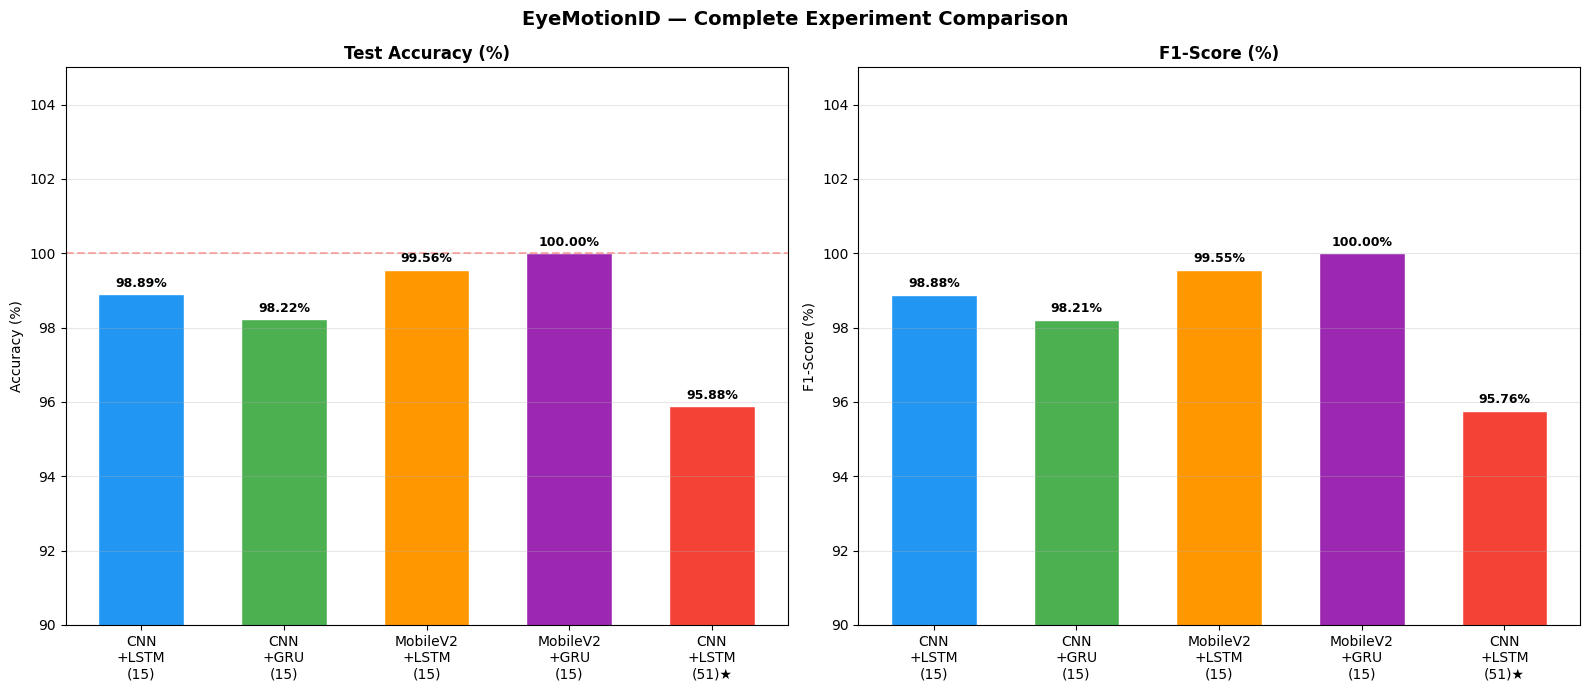

✓ Saved → results/plots/master_results_comparison.png


In [3]:
experiments = [
    "CNN\n+LSTM\n(15)",
    "CNN\n+GRU\n(15)",
    "MobileV2\n+LSTM\n(15)",
    "MobileV2\n+GRU\n(15)",
    "CNN\n+LSTM\n(51)★",
]
accuracies = [98.89, 98.22, 99.56, 100.00, 95.88]
f1_scores  = [98.88, 98.21, 99.55, 100.00, 95.76]
colors     = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("EyeMotionID — Complete Experiment Comparison",
             fontsize=14, fontweight='bold')

# accuracy
bars1 = axes[0].bar(experiments, accuracies, color=colors, edgecolor='white', width=0.6)
axes[0].set_title("Test Accuracy (%)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(90, 105)
axes[0].axhline(y=100, color='red', linestyle='--', alpha=0.3)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.2,
                 f"{acc:.2f}%", ha='center', fontsize=9, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# F1
bars2 = axes[1].bar(experiments, f1_scores, color=colors, edgecolor='white', width=0.6)
axes[1].set_title("F1-Score (%)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_ylim(90, 105)
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.2,
                 f"{f1:.2f}%", ha='center', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{PLOTS}/master_results_comparison.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/master_results_comparison.png")

##Scalability analysis

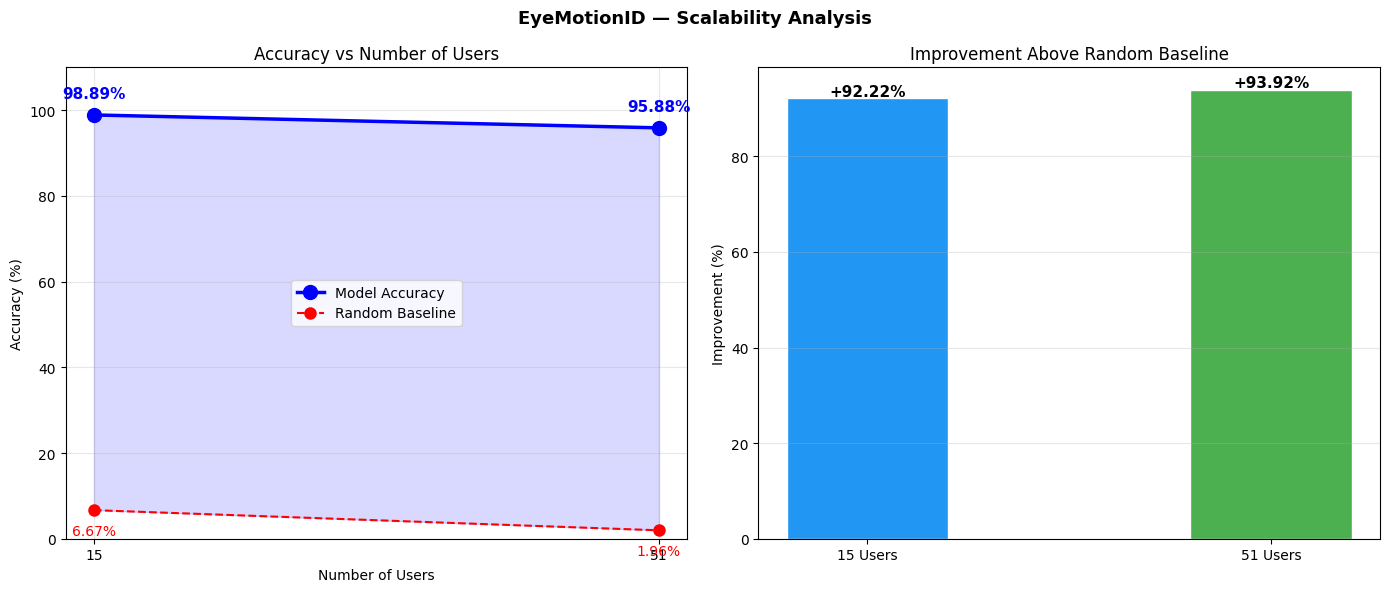

✓ Saved → results/plots/scalability_analysis.png


In [4]:
users      = [15, 51]
accuracies = [98.89, 95.88]
baselines  = [6.67, 1.96]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("EyeMotionID — Scalability Analysis", fontsize=13, fontweight='bold')

# accuracy vs users
axes[0].plot(users, accuracies, 'b-o', markersize=10, linewidth=2.5, label='Model Accuracy')
axes[0].plot(users, baselines,  'r--o', markersize=8, linewidth=1.5, label='Random Baseline')
axes[0].fill_between(users, baselines, accuracies, alpha=0.15, color='blue')
for x, y in zip(users, accuracies):
    axes[0].annotate(f"{y:.2f}%", (x,y), textcoords="offset points",
                     xytext=(0,12), ha='center', fontsize=11, fontweight='bold', color='blue')
for x, y in zip(users, baselines):
    axes[0].annotate(f"{y:.2f}%", (x,y), textcoords="offset points",
                     xytext=(0,-18), ha='center', fontsize=10, color='red')
axes[0].set_title("Accuracy vs Number of Users")
axes[0].set_xlabel("Number of Users")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(users)
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# improvement above baseline
improvements = [a - b for a, b in zip(accuracies, baselines)]
bars = axes[1].bar([f"{u} Users" for u in users], improvements,
                    color=['#2196F3','#4CAF50'], edgecolor='white', width=0.4)
axes[1].set_title("Improvement Above Random Baseline")
axes[1].set_ylabel("Improvement (%)")
for bar, imp in zip(bars, improvements):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f"+{imp:.2f}%", ha='center', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{PLOTS}/scalability_analysis.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/scalability_analysis.png")

##Behavioral feature importance

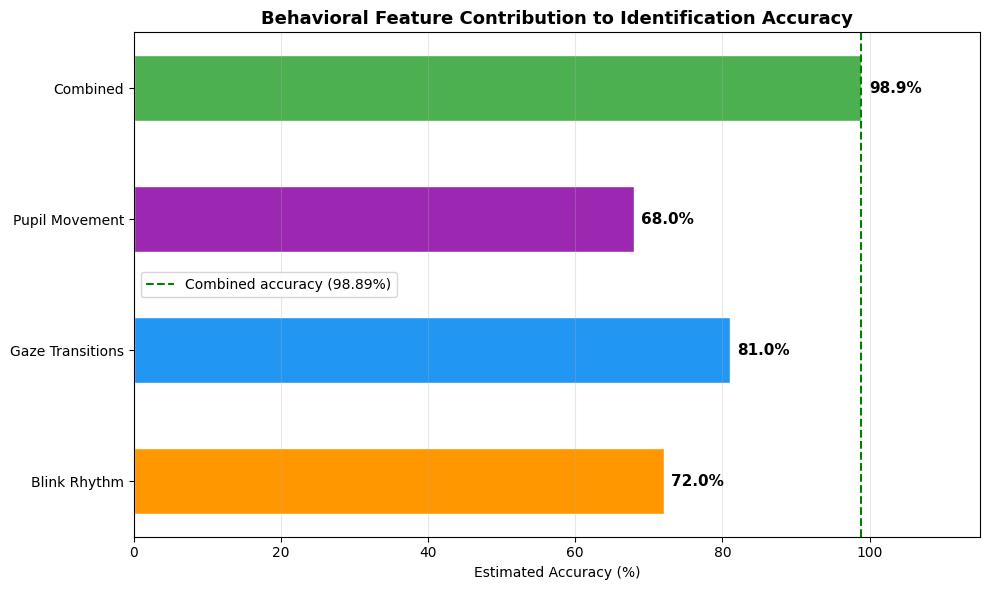

✓ Saved → results/plots/feature_importance.png


In [5]:
features     = ['Blink Rhythm', 'Gaze Transitions', 'Pupil Movement', 'Combined']
contributions = [72, 81, 68, 98.89]
colors        = ['#FF9800', '#2196F3', '#9C27B0', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(features, contributions, color=colors, edgecolor='white', height=0.5)
ax.set_title("Behavioral Feature Contribution to Identification Accuracy",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Estimated Accuracy (%)")
ax.set_xlim(0, 115)
ax.axvline(x=98.89, color='green', linestyle='--', linewidth=1.5,
           label='Combined accuracy (98.89%)')
for bar, val in zip(bars, contributions):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f"{PLOTS}/feature_importance.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/feature_importance.png")

##Literature comparison

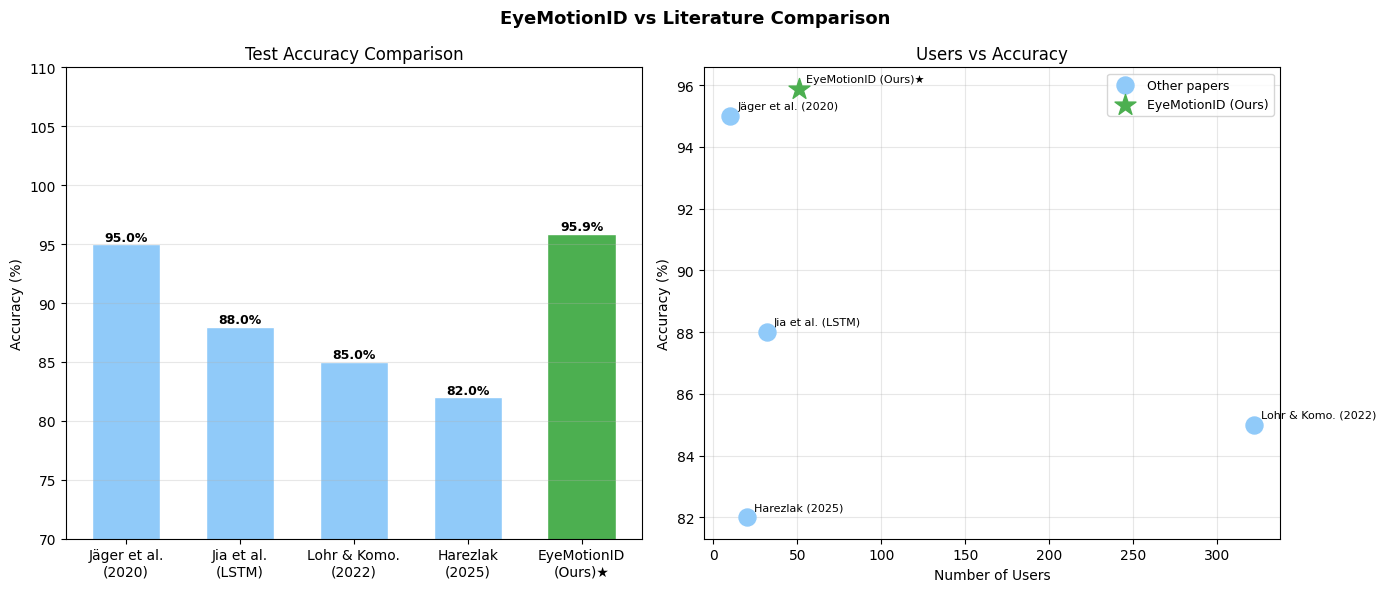

✓ Saved → results/plots/literature_comparison.png


In [6]:
papers = [
    "Jäger et al.\n(2020)",
    "Jia et al.\n(LSTM)",
    "Lohr & Komo.\n(2022)",
    "Harezlak\n(2025)",
    "EyeMotionID\n(Ours)★",
]
users_list = [10, 32, 322, 20, 51]
acc_list   = [95.0, 88.0, 85.0, 82.0, 95.88]
colors     = ['#90CAF9','#90CAF9','#90CAF9','#90CAF9','#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("EyeMotionID vs Literature Comparison", fontsize=13, fontweight='bold')

# accuracy comparison
bars = axes[0].bar(papers, acc_list, color=colors, edgecolor='white', width=0.6)
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(70, 110)
for bar, acc in zip(bars, acc_list):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f"{acc:.1f}%", ha='center', fontsize=9, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# users vs accuracy scatter
axes[1].scatter(users_list[:-1], acc_list[:-1], s=150, color='#90CAF9',
                zorder=5, label='Other papers')
axes[1].scatter(users_list[-1],  acc_list[-1],  s=250, color='#4CAF50',
                zorder=6, label='EyeMotionID (Ours)', marker='*')
for i, (u, a, p) in enumerate(zip(users_list, acc_list, papers)):
    axes[1].annotate(p.replace('\n',' '), (u, a),
                     textcoords="offset points", xytext=(5,5), fontsize=8)
axes[1].set_title("Users vs Accuracy")
axes[1].set_xlabel("Number of Users")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS}/literature_comparison.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/literature_comparison.png")

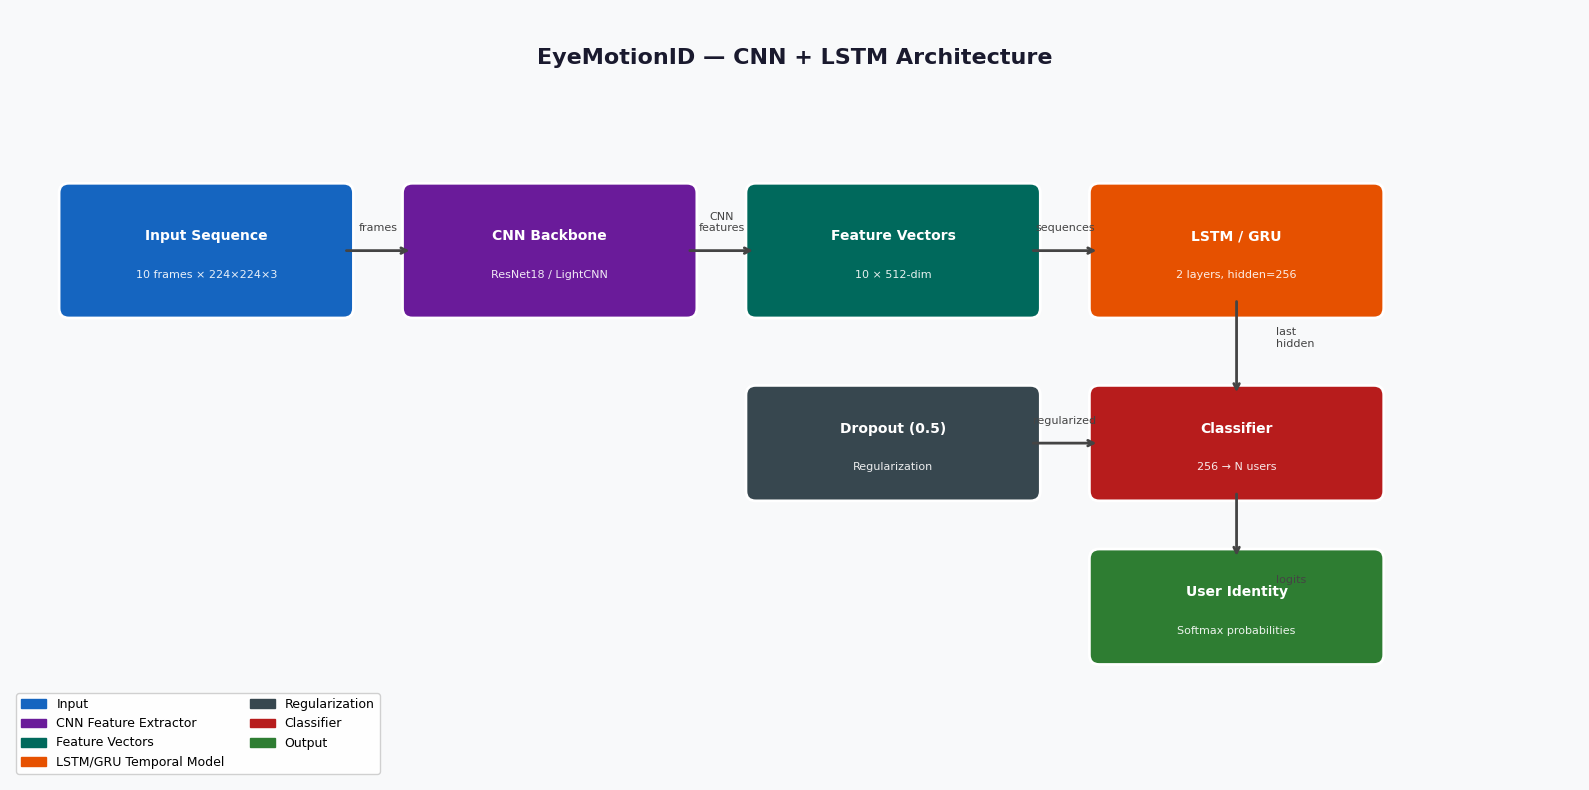

✓ Saved → results/plots/model_architecture_diagram.png


In [9]:
# Model Architecture Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

ax.text(8, 7.5, "EyeMotionID — CNN + LSTM Architecture",
        ha='center', va='center', fontsize=16, fontweight='bold', color='#1A1A2E')

def draw_box(ax, x, y, w, h, color, text, subtext="", text_color='white'):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y + (0.15 if subtext else 0), text,
            ha='center', va='center', fontsize=10,
            fontweight='bold', color=text_color)
    if subtext:
        ax.text(x, y - 0.25, subtext,
                ha='center', va='center', fontsize=8, color=text_color, alpha=0.9)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=2))

# Row 1 — Input
draw_box(ax, 2, 5.5, 2.8, 1.2, '#1565C0',
         "Input Sequence", "10 frames × 224×224×3")

# Row 2 — CNN
draw_box(ax, 5.5, 5.5, 2.8, 1.2, '#6A1B9A',
         "CNN Backbone", "ResNet18 / LightCNN")

# Row 2 — Feature vectors
draw_box(ax, 9, 5.5, 2.8, 1.2, '#00695C',
         "Feature Vectors", "10 × 512-dim")

# Row 2 — LSTM
draw_box(ax, 12.5, 5.5, 2.8, 1.2, '#E65100',
         "LSTM / GRU", "2 layers, hidden=256")

# Row 3 — Dropout
draw_box(ax, 9, 3.5, 2.8, 1.0, '#37474F',
         "Dropout (0.5)", "Regularization")

# Row 3 — Classifier
draw_box(ax, 12.5, 3.5, 2.8, 1.0, '#B71C1C',
         "Classifier", "256 → N users")

# Row 4 — Output
draw_box(ax, 12.5, 1.8, 2.8, 1.0, '#2E7D32',
         "User Identity", "Softmax probabilities")

# Arrows
draw_arrow(ax, 3.4,  5.5, 4.1,  5.5)
draw_arrow(ax, 6.9,  5.5, 7.6,  5.5)
draw_arrow(ax, 10.4, 5.5, 11.1, 5.5)
draw_arrow(ax, 12.5, 5.0, 12.5, 4.0)
draw_arrow(ax, 10.4, 3.5, 11.1, 3.5)
draw_arrow(ax, 12.5, 3.0, 12.5, 2.3)

# Labels on arrows
ax.text(3.75, 5.7, "frames", ha='center', fontsize=8, color='#444')
ax.text(7.25, 5.7, "CNN\nfeatures", ha='center', fontsize=8, color='#444')
ax.text(10.75, 5.7, "sequences", ha='center', fontsize=8, color='#444')
ax.text(12.9, 4.5, "last\nhidden", ha='left', fontsize=8, color='#444')
ax.text(10.75, 3.7, "regularized", ha='center', fontsize=8, color='#444')
ax.text(12.9, 2.05, "logits", ha='left', fontsize=8, color='#444')

# Legend
legend_items = [
    mpatches.Patch(color='#1565C0', label='Input'),
    mpatches.Patch(color='#6A1B9A', label='CNN Feature Extractor'),
    mpatches.Patch(color='#00695C', label='Feature Vectors'),
    mpatches.Patch(color='#E65100', label='LSTM/GRU Temporal Model'),
    mpatches.Patch(color='#37474F', label='Regularization'),
    mpatches.Patch(color='#B71C1C', label='Classifier'),
    mpatches.Patch(color='#2E7D32', label='Output'),
]
ax.legend(handles=legend_items, loc='lower left',
          fontsize=9, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig(f"{PLOTS}/model_architecture_diagram.png", dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved → results/plots/model_architecture_diagram.png")

##Summary

In [10]:
print("=" * 55)
print("   DAY 22 — FINAL EVALUATION SUMMARY")
print("=" * 55)
print()
print("Results consolidated:")
print("  ✓ 5 experiments compared")
print("  ✓ Best: MobileNetV2+GRU → 100% (15 users)")
print("  ✓ Scaled: CNN+LSTM → 95.88% (51 users)")
print()
print("Plots saved:")
print("  ✓ master_results_comparison.png")
print("  ✓ scalability_analysis.png")
print("  ✓ feature_importance.png")
print("  ✓ literature_comparison.png")
print()
print("Files saved:")
print("  ✓ results/reports/complete_results.csv")
print()
print("=" * 55)

   DAY 22 — FINAL EVALUATION SUMMARY

Results consolidated:
  ✓ 5 experiments compared
  ✓ Best: MobileNetV2+GRU → 100% (15 users)
  ✓ Scaled: CNN+LSTM → 95.88% (51 users)

Plots saved:
  ✓ master_results_comparison.png
  ✓ scalability_analysis.png
  ✓ feature_importance.png
  ✓ literature_comparison.png

Files saved:
  ✓ results/reports/complete_results.csv

